# Halo catalogs — Gadget vs PDS, matched frame (1200 Mpc trio & 50 Mpc pair)

Representative analysis of the StePS_HF halo catalogs built for the five flagship runs.
**Data dependency:** catalogs under `/scratch/csabai/halo_catalogs{,50}/` (built by the
`prep_cut_snapshots*.py` + StePS_HF + `postprocess*.py` pipeline documented there and in
`docs/PDS_guide.md`).

**Pipeline essentials**
- **Matched frame:** PDS stereographic coordinates (origin-centred, Mpc); Gadget
  `x/h − L/2` (Mpc/h → Mpc, then the FFT-verified −L/2 shift; beware
  `np.mod(x+L/2,L)−L/2` — it is a *no-op relabeling*, not this shift).
- **Common volume:** a cube fully inside the dodecahedral fundamental domain
  (±300 Mpc @1200; ±11.5 Mpc @50) + a buffer ≥ the finder search radius.
- **PDS mass de-conformalization:** native masses carry the conformal-volume factor;
  the matched-frame mass is m/Ω(r)³ at the particle's current position. For a grid load
  this recovers Gadget's particle mass to 0.06%; for a glass it varies a few % and is
  quantized to 32 levels (StePS_HF scans `np.unique(Masses)`).
- **StePS_HF settings:** SO finder, kNN(10) density, PERIODIC mode on the cut box (fake
  periodicity only touches the discarded buffer), SEARCH_RADIUS > largest R200b
  (8 Mpc @1200, 3 Mpc @50), NPARTMIN=10, no unbinding. Particle IDs must be 0..N−1.

In [1]:
import numpy as np, h5py
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
plt.style.use('dark_background')

CATS_1200 = {
    'Gadget256 (flat, grid IC)': '/scratch/csabai/halo_catalogs/gadget256_z0_matchedframe_halos.hdf5',
    'PDS grid-IC':               '/scratch/csabai/halo_catalogs/pds_grid256_z0_matchedframe_halos.hdf5',
    'PDS glass-IC':              '/scratch/csabai/halo_catalogs/pds_glass256_z0_matchedframe_halos.hdf5',
}
CATS_50 = {
    'Gadget50 (flat, glass IC)': '/scratch/csabai/halo_catalogs50/gadget50_z0_matchedframe_halos.hdf5',
    'PDS50 (glass IC)':          '/scratch/csabai/halo_catalogs50/pds50glass_z0_matchedframe_halos.hdf5',
}
def load_cat(fn):
    with h5py.File(fn, 'r') as f:
        g = f['Halos']
        return {k: g[k][:] for k in ('Coordinates', 'Mvir', 'Npart', 'Rvir')}
c1200 = {n: load_cat(f) for n, f in CATS_1200.items()}
c50   = {n: load_cat(f) for n, f in CATS_50.items()}
for n, c in {**c1200, **c50}.items():
    print(f'{n:28s} N={len(c["Mvir"]):6d}   Mvir max={c["Mvir"].max():.2e} Msol')

Gadget256 (flat, grid IC)    N= 13931   Mvir max=2.97e+15 Msol
PDS grid-IC                  N= 13614   Mvir max=2.72e+15 Msol
PDS glass-IC                 N= 25460   Mvir max=2.55e+15 Msol
Gadget50 (flat, glass IC)    N= 10794   Mvir max=3.59e+13 Msol
PDS50 (glass IC)             N=  7944   Mvir max=3.80e+13 Msol


## 1. Cumulative mass functions
Left: 1200 Mpc trio (600 Mpc cube). Gadget and PDS-grid overlap across the full range —
the PDS dynamics reproduce the flat reference halo statistics. The PDS glass run shows a
~1.7× abundance excess (matches its ~30% high-k P(k) excess; open issue, suspect residual
glass-load noise — do not trust its halo *masses* yet). Right: 50 Mpc pair (23 Mpc cube),
tracking each other over 3.5 decades; the offset reflects their different (topology-
dominated) large-scale modes.

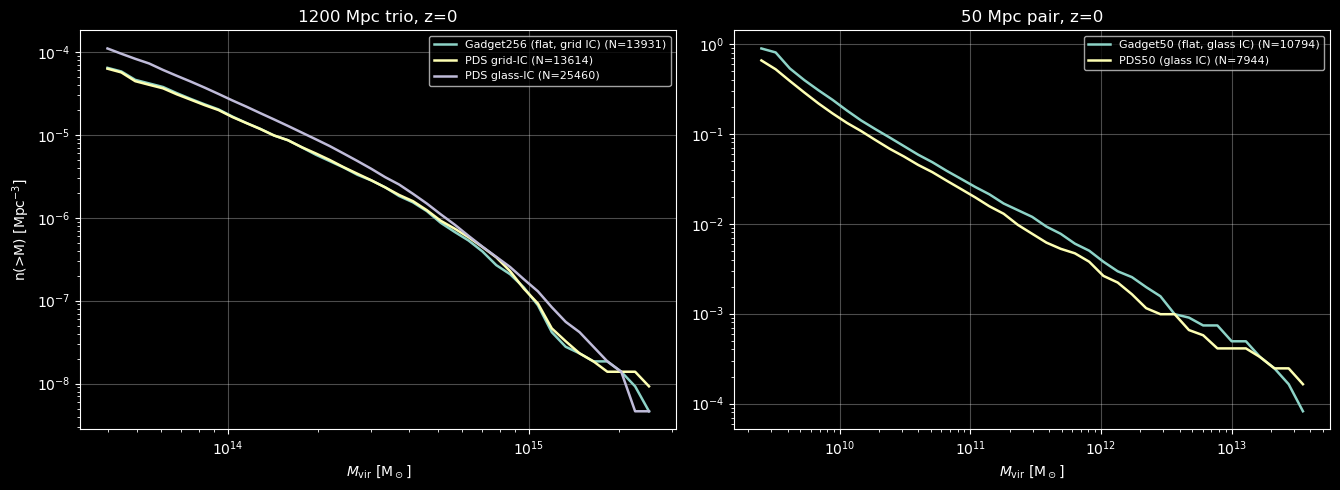

In [2]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 5))
for n, c in c1200.items():
    m = np.logspace(13.6, 15.4, 40)
    N = np.array([(c['Mvir'] > x).sum() for x in m], float)
    a1.loglog(m[N > 0], N[N > 0]/600.0**3, lw=1.8, label=f'{n} (N={len(c["Mvir"])})')
a1.set_xlabel(r'$M_{\rm vir}$ [M$_\odot$]'); a1.set_ylabel(r'n(>M) [Mpc$^{-3}$]')
a1.set_title('1200 Mpc trio, z=0'); a1.legend(fontsize=8); a1.grid(alpha=0.3)
for n, c in c50.items():
    m = np.logspace(9.4, 14.2, 45)
    N = np.array([(c['Mvir'] > x).sum() for x in m], float)
    a2.loglog(m[N > 0], N[N > 0]/23.0**3, lw=1.8, label=f'{n} (N={len(c["Mvir"])})')
a2.set_xlabel(r'$M_{\rm vir}$ [M$_\odot$]')
a2.set_title('50 Mpc pair, z=0'); a2.legend(fontsize=8); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Halo-by-halo cross-match (1200 Mpc)
The three 1200 Mpc runs share the seed-137 realization, so individual halos can be matched
by position (criterion d < 5 Mpc: the grid-IC nearest-Gadget distance CDF reaches 99% by
5 Mpc while random positions give ~2%). **98% of the top-500 PDS grid-IC halos have a
Gadget counterpart** (median offset 2.4 Mpc, median mass ratio 1.10). Note: the 50 Mpc pair
cannot be cross-matched — their z=0 fields physically decorrelate (different topology
modes), which is a result, not an error.

PDS grid-IC: top-500 match fraction = 0.98, median offset = 2.43 Mpc, median mass ratio = 1.10
PDS glass-IC: top-500 match fraction = 0.62, median offset = 3.45 Mpc, median mass ratio = 2.18


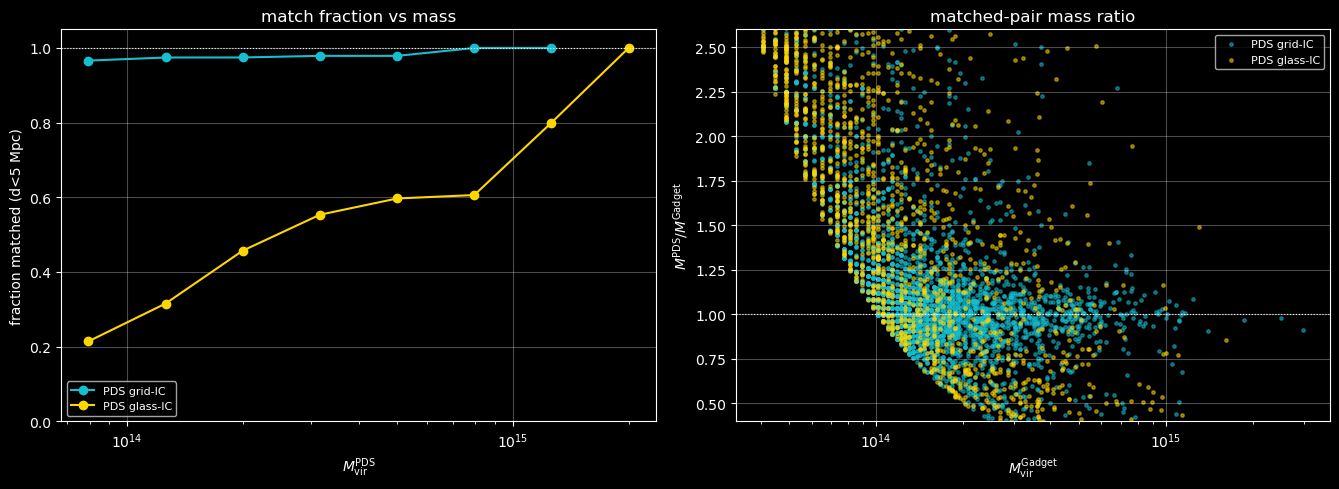

In [3]:
ref = c1200['Gadget256 (flat, grid IC)']
tree = cKDTree(ref['Coordinates'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5))
for n, col in [('PDS grid-IC', 'tab:cyan'), ('PDS glass-IC', 'gold')]:
    c = c1200[n]; o = np.argsort(c['Mvir'])[::-1]
    d, j = tree.query(c['Coordinates'][o])
    matched = d < 5.0
    mb = np.logspace(13.8, 15.4, 9); cen, frac = [], []
    for lo, hi in zip(mb[:-1], mb[1:]):
        s = (c['Mvir'][o] >= lo) & (c['Mvir'][o] < hi)
        if s.sum() >= 5: cen.append(np.sqrt(lo*hi)); frac.append(matched[s].mean())
    ax1.semilogx(cen, frac, marker='o', color=col, label=n)
    s = matched & (c['Mvir'][o] > 1e14)
    ax2.scatter(ref['Mvir'][j][s], c['Mvir'][o][s]/ref['Mvir'][j][s], s=6, alpha=0.5,
                color=col, label=n)
    print(f'{n}: top-500 match fraction = {matched[:500].mean():.2f}, '
          f'median offset = {np.median(d[s]):.2f} Mpc, '
          f'median mass ratio = {np.median(c["Mvir"][o][s]/ref["Mvir"][j][s]):.2f}')
ax1.axhline(1, color='w', ls=':', lw=0.8); ax1.set_ylim(0, 1.05)
ax1.set_xlabel(r'$M_{\rm vir}^{\rm PDS}$'); ax1.set_ylabel('fraction matched (d<5 Mpc)')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3); ax1.set_title('match fraction vs mass')
ax2.set_xscale('log'); ax2.axhline(1, color='w', ls=':', lw=0.8); ax2.set_ylim(0.4, 2.6)
ax2.set_xlabel(r'$M_{\rm vir}^{\rm Gadget}$'); ax2.set_ylabel(r'$M^{\rm PDS}/M^{\rm Gadget}$')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3); ax2.set_title('matched-pair mass ratio')
plt.tight_layout(); plt.show()

### Notes
- PDS catalogs additionally contain `Omega_center`, `M*_phys = M·Ω³`, `R*_phys = R·Ω`
  columns (physical S³ values); the main columns are matched-frame quantities directly
  comparable to Gadget.
- Full pipeline, raw finder outputs and README: `/scratch/csabai/halo_catalogs{,50}/`.